# Laboratorio 4 – Árboles de Decisión
**CC3074 – Minería de Datos | Universidad del Valle de Guatemala | Semestre I 2026**

**Contexto:** SmartStay Advisors necesita modelos para estimar precios de propiedades Airbnb, identificar propiedades con baja ocupación y comprender qué factores influyen en los ingresos.

**Variable respuesta:** `price` (precio por noche en moneda local)

In [45]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')
random.seed(123)

---
## Actividad 1 – Carga del dataset

In [46]:
result = pyreadr.read_r('listings.RData')
df = result['listings'].copy()
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head(3)

Dataset cargado: 171,748 filas × 80 columnas

Columnas: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availabili

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


El dataset contiene **171,748 anuncios** y **80 variables** que describen propiedades Airbnb: características físicas, del anfitrión, disponibilidad, reseñas y ubicación.

---
## Actividad 2 – Análisis Exploratorio de Datos (EDA)

### 2.1 Preprocesamiento de `price`

La variable `price` viene en formato texto (`$97.00`). Se remueven los símbolos `$` y `,`, se convierte a numérico y se eliminan registros con precio cero o nulo.

In [47]:
print('Formato original de price:', df['price'].head(5).tolist())

df['price'] = df['price'].str.replace('[$,]', '', regex=True).str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

n_antes = len(df)
df = df[df['price'] > 0].dropna(subset=['price'])
print(f'Filas eliminadas (price <= 0 o nulo): {n_antes - len(df):,}')
print(f'Dataset final: {len(df):,} filas')

Formato original de price: ['$97.00', '$160.00', '$38.00', '$145.00', '$58.00']
Filas eliminadas (price <= 0 o nulo): 95,502
Dataset final: 76,246 filas


Se eliminaron **95,502 registros** (55% del total) que no tenían precio asignado. Esto es esperado en Airbnb: muchos anuncios existen pero no están activos con precio publicado. El análisis continúa con **76,246 propiedades** con precio válido.

### 2.2 Valores faltantes

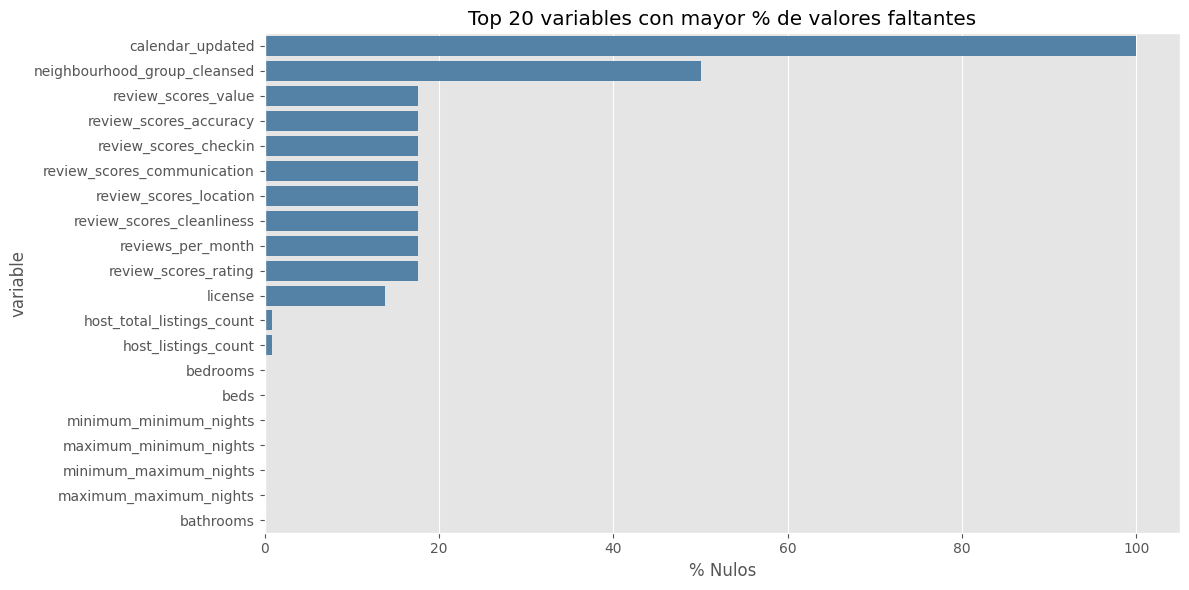

Variables con >50% nulos: 1
                    variable   pct_nulo
            calendar_updated 100.000000
neighbourhood_group_cleansed  49.997377
         review_scores_value  17.596989
      review_scores_accuracy  17.596989
       review_scores_checkin  17.596989
 review_scores_communication  17.596989
      review_scores_location  17.596989
   review_scores_cleanliness  17.596989
           reviews_per_month  17.591743
        review_scores_rating  17.591743
                     license  13.793510
   host_total_listings_count   0.822338
         host_listings_count   0.822338
                    bedrooms   0.158697
                        beds   0.104924


In [48]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['variable', 'pct_nulo']

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df.head(20), x='pct_nulo', y='variable', color='steelblue')
plt.title('Top 20 variables con mayor % de valores faltantes')
plt.xlabel('% Nulos')
plt.tight_layout()
plt.show()

print(f'Variables con >50% nulos: {(missing > 50).sum()}')
print(missing_df.head(15).to_string(index=False))

**Hallazgos:**
- `calendar_updated` tiene **100% de nulos** — se eliminará.
- `neighbourhood_group_cleansed` tiene **50% de nulos** — se usará `neighbourhood_cleansed` como alternativa.
- Las variables de `review_scores_*` y `reviews_per_month` tienen **~17.6% de nulos**, correspondiente a propiedades sin reseñas aún. Se imputarán con la mediana.
- `license` tiene 13.8% de nulos y tiene baja utilidad predictiva — se eliminará.

### 2.3 Distribución de `price`

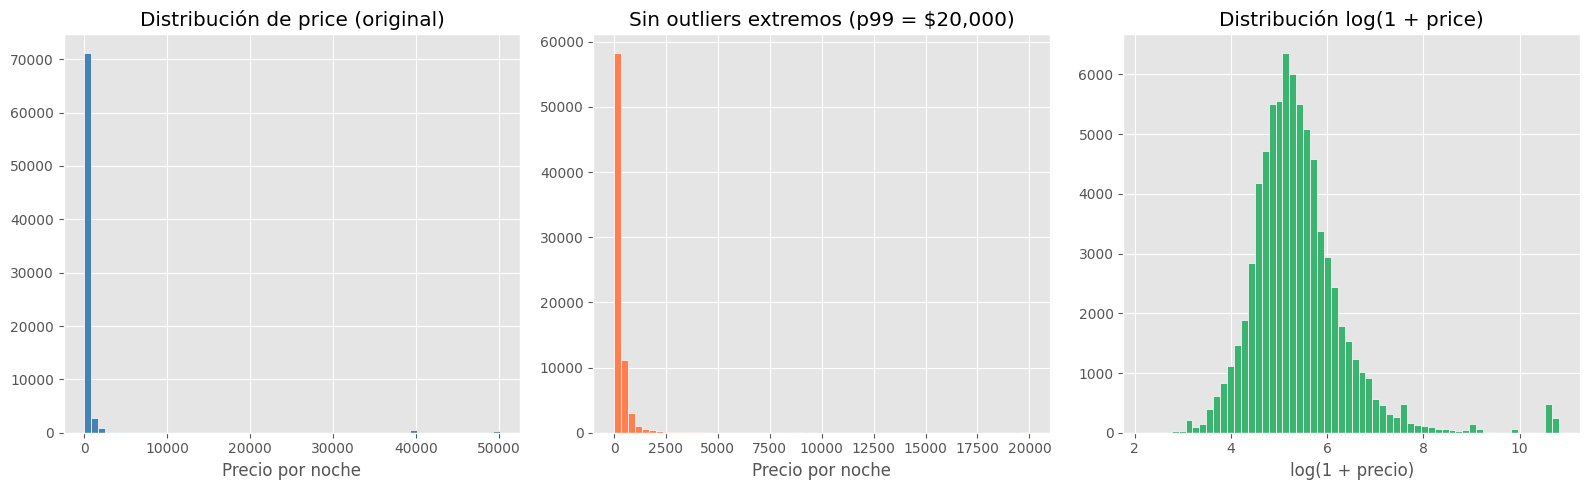

count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price, dtype: float64

Skewness: 9.87
P25=$120 | Mediana=$193 | P75=$326 | P99=$20,000


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de price (original)')
axes[0].set_xlabel('Precio por noche')

p99 = df['price'].quantile(0.99)
axes[1].hist(df[df['price'] <= p99]['price'], bins=60, color='coral', edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (p99 = ${p99:,.0f})')
axes[1].set_xlabel('Precio por noche')

axes[2].hist(np.log1p(df['price']), bins=60, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribución log(1 + price)')
axes[2].set_xlabel('log(1 + precio)')

plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))
print(f'\nSkewness: {df["price"].skew():.2f}')
print(f'P25=${df["price"].quantile(0.25):.0f} | Mediana=${df["price"].quantile(0.5):.0f} | P75=${df["price"].quantile(0.75):.0f} | P99=${df["price"].quantile(0.99):,.0f}')

**Hallazgos:**
- La distribución tiene una **asimetría extrema (skewness = 9.87)**: la mayoría de propiedades tiene precios entre $120 y $326, pero existen valores hasta $50,123.
- **Mediana = $193**, **media = $750** — la gran diferencia indica que los outliers (hoteles de lujo, propiedades Premium) jalan la media hacia arriba.
- La transformación logarítmica produce una distribución mucho más simétrica, lo que podría beneficiar los modelos lineales en actividades posteriores.
- Para la categorización (Actividad 9) se usarán los percentiles de la distribución real para definir límites robustos.

### 2.4 Precio por tipo de habitación (`room_type`)

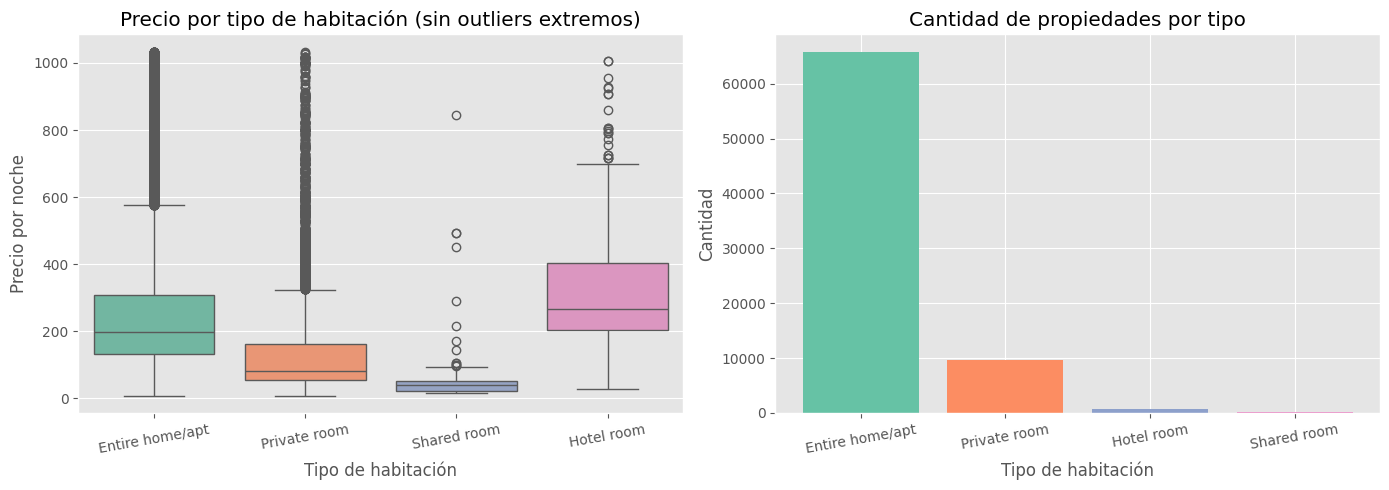

                   count      mean       std   min    25%      50%      75%  \
room_type                                                                     
Entire home/apt  65709.0    505.12   2591.83   8.0  135.0    205.0    340.0   
Hotel room         649.0  24477.20  21965.65  28.0  325.0  40000.0  40000.0   
Private room      9673.0    838.87   5123.61   8.0   55.0     85.0    178.0   
Shared room        215.0    149.37    820.84  15.0   22.5     42.0     52.0   

                     max  
room_type                 
Entire home/apt  50000.0  
Hotel room       50032.0  
Private room     50123.0  
Shared room       7000.0  


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = df['price'].quantile(0.95)
sns.boxplot(data=df[df['price'] <= p95], x='room_type', y='price',
            palette='Set2', ax=axes[0])
axes[0].set_title('Precio por tipo de habitación (sin outliers extremos)')
axes[0].set_xlabel('Tipo de habitación')
axes[0].set_ylabel('Precio por noche')
axes[0].tick_params(axis='x', rotation=10)

room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values,
            color=sns.color_palette('Set2', len(room_counts)))
axes[1].set_title('Cantidad de propiedades por tipo')
axes[1].set_xlabel('Tipo de habitación')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

print(df.groupby('room_type')['price'].describe().round(2))

**Hallazgos:**
- **Entire home/apt** domina el dataset con 65,709 propiedades (86%) y precio mediano de $205.
- **Hotel room** (649 registros, <1%) tiene precios extremadamente altos (media $24,477, mediana $40,000). Esto apunta a que los hoteles de lujo están en una categoría completamente diferente y pueden actuar como outliers influyentes en el modelo.
- **Private room** tiene precio mediano de $85 — significativamente menor al alojamiento completo.
- **Shared room** es la categoría más económica con precio mediano de $42.
- `room_type` es una variable altamente predictiva del precio y será fundamental en el modelo.

### 2.5 Precio por capacidad de huéspedes (`accommodates`)

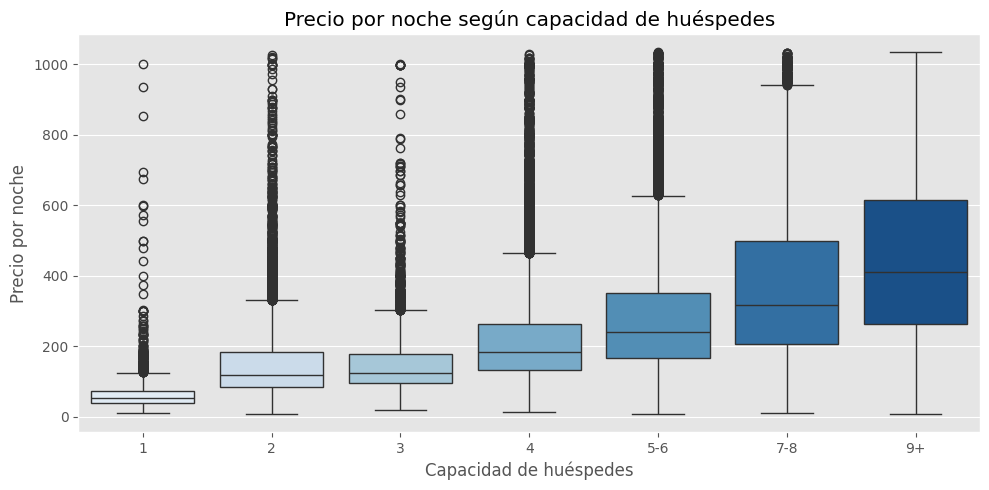

Precio mediano por capacidad (primeros 10):
accommodates
1      54.0
2     121.0
3     128.0
4     186.0
5     190.0
6     265.0
7     260.0
8     388.0
9     334.0
10    436.0
Name: price, dtype: float64


In [51]:
df_acc = df.copy()
df_acc['acc_group'] = pd.cut(df_acc['accommodates'],
                              bins=[0,1,2,3,4,6,8,50],
                              labels=['1','2','3','4','5-6','7-8','9+'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_acc[df_acc['price'] <= p95],
            x='acc_group', y='price', palette='Blues')
plt.title('Precio por noche según capacidad de huéspedes')
plt.xlabel('Capacidad de huéspedes')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print('Precio mediano por capacidad (primeros 10):')
print(df.groupby('accommodates')['price'].median().head(10).round(2))

**Hallazgos:**
- Existe una relación positiva clara entre capacidad y precio: desde $54 (1 huésped) hasta $436 (10 huéspedes).
- La relación no es perfectamente lineal — hay saltos entre 7-8 y 9+ huéspedes donde el precio sube considerablemente.
- Esta variable es uno de los mejores predictores individuales del precio.

### 2.6 Correlación de variables numéricas con `price`

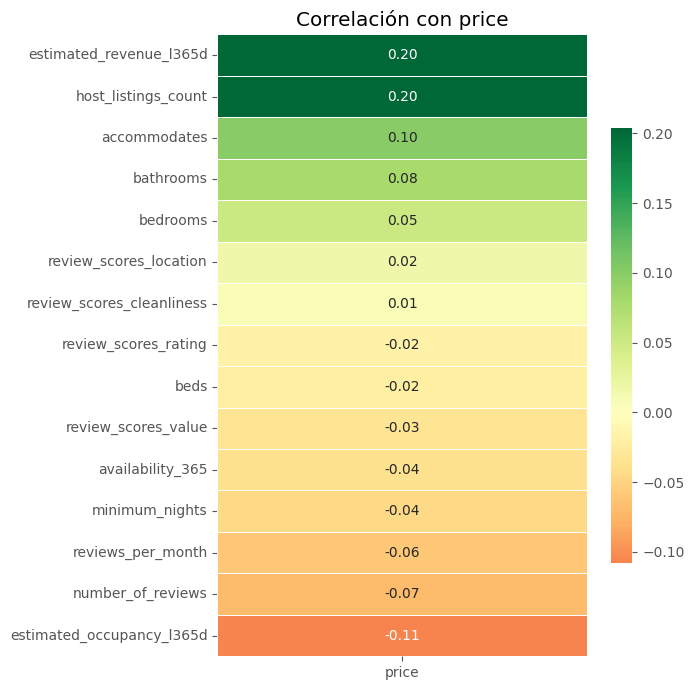

In [52]:
num_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'host_listings_count',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d'
]
num_cols = [c for c in num_cols if c in df.columns]

df_num = df[num_cols].copy()
for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

corr = df_num.corr()[['price']].drop('price').sort_values('price', ascending=False)

plt.figure(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlación con price')
plt.tight_layout()
plt.show()

**Hallazgos:**
- Las variables con mayor correlación positiva con `price` son `accommodates`, `bedrooms`, `beds` y `bathrooms` — propiedades más grandes cuestan más.
- `estimated_revenue_l365d` tiene correlación alta esperada (el ingreso anual depende del precio diario).
- Las puntuaciones de reviews tienen correlaciones bajas o negativas con el precio: propiedades caras no necesariamente reciben mejores calificaciones.
- `minimum_nights` y `availability_365` tienen correlaciones muy bajas, indicando que la política de reservas no determina el precio.

### 2.7 Superhost vs precio

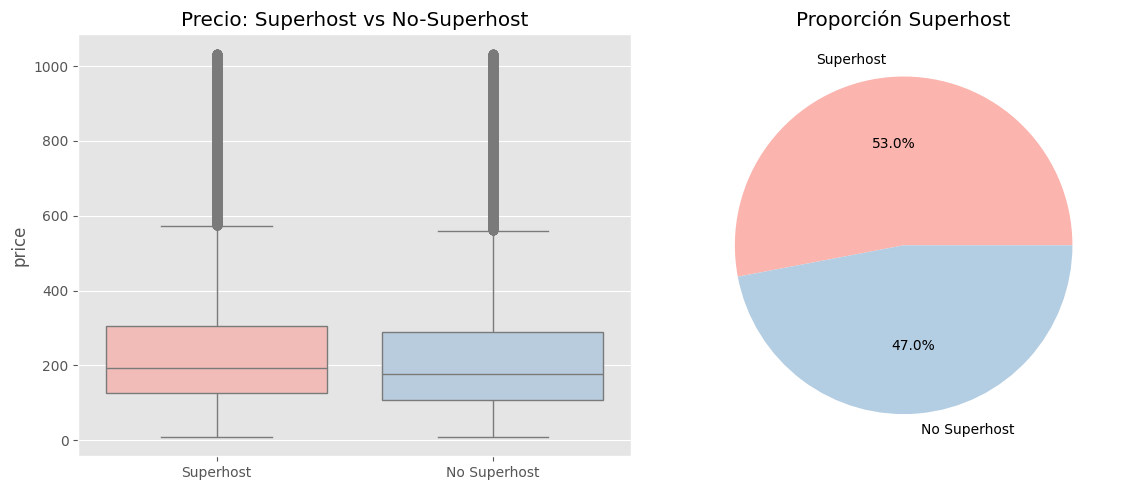

                count     mean      std  min    25%    50%    75%      max
es_superhost                                                              
No Superhost  34898.0  1188.09  6168.93  8.0  111.0  185.0  317.0  50123.0
Superhost     39321.0   388.75   969.08  8.0  129.0  202.0  339.0  50000.0


In [53]:
df_sh = df[df['host_is_superhost'].isin(['t','f'])].copy()
df_sh['es_superhost'] = df_sh['host_is_superhost'].map({'t':'Superhost','f':'No Superhost'})

p95 = df['price'].quantile(0.95)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_sh[df_sh['price'] <= p95], x='es_superhost', y='price',
            palette='Pastel1', ax=axes[0])
axes[0].set_title('Precio: Superhost vs No-Superhost')
axes[0].set_xlabel('')

counts = df_sh['es_superhost'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Pastel1'))
axes[1].set_title('Proporción Superhost')

plt.tight_layout()
plt.show()

print(df_sh.groupby('es_superhost')['price'].describe().round(2))

**Hallazgos:**
- Los Superhosts tienen precio mediano ligeramente mayor ($202) que los No-Superhosts ($185), pero la diferencia no es drástica.
- Los Superhosts representan la mayoría del dataset, lo que sugiere que el programa de Superhost tiene alta penetración en las ciudades analizadas.
- La distinción Superhost no es el factor dominante del precio, pero puede ser relevante como variable de control.

### 2.8 Disponibilidad anual vs precio

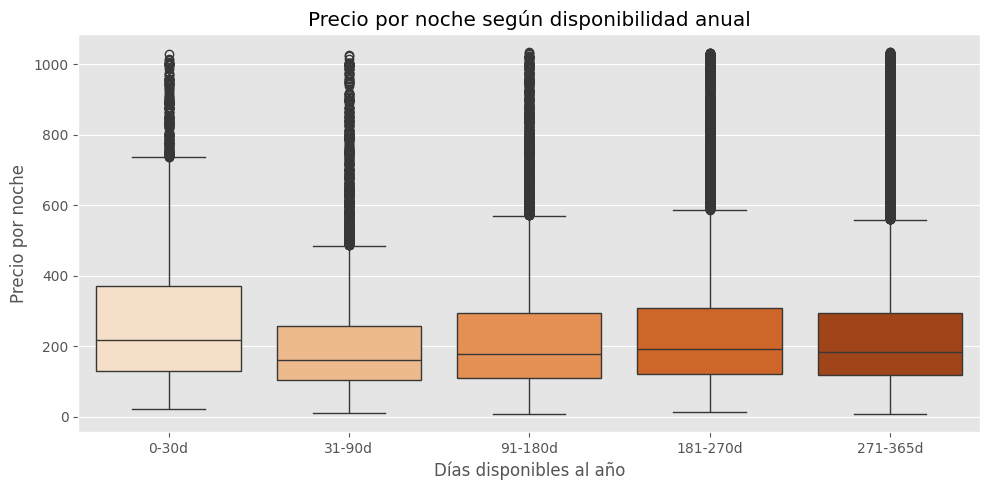

               count     mean       std   min     25%    50%     75%      max
avail_group                                                                  
0-30d         3900.0  3085.11  10427.89  22.0  138.75  240.0  452.25  50000.0
31-90d        8389.0   304.42   1524.09  10.0  108.00  166.0  271.00  50000.0
91-180d      12140.0   510.70   2428.14   8.0  113.00  185.0  322.00  50000.0
181-270d     18788.0   621.41   3230.97  13.0  127.00  203.0  350.25  50000.0
271-365d     33029.0   749.73   4410.50   8.0  121.00  193.0  319.00  50123.0


In [54]:
df['avail_group'] = pd.cut(df['availability_365'],
                            bins=[-1, 30, 90, 180, 270, 365],
                            labels=['0-30d','31-90d','91-180d','181-270d','271-365d'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['price'] <= p95], x='avail_group', y='price', palette='Oranges')
plt.title('Precio por noche según disponibilidad anual')
plt.xlabel('Días disponibles al año')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print(df.groupby('avail_group')['price'].describe().round(2))

**Hallazgos:**
- La disponibilidad anual promedio es de **231 días** (mediana=256), indicando que la mayoría de propiedades está disponible más de la mitad del año.
- No hay una tendencia clara entre disponibilidad y precio — propiedades con alta y baja disponibilidad pueden tener precios similares.
- Esto sugiere que la disponibilidad responde más a la estrategia del anfitrión que al precio de la propiedad.

### 2.9 Preprocesamiento final del dataset para modelado

In [55]:
# Columnas a descartar: identificadores, URLs, texto libre, fechas
cols_drop = [
    'id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_name','host_since','host_location','host_about',
    'host_thumbnail_url','host_picture_url','host_verifications',
    'neighbourhood','calendar_updated','calendar_last_scraped',
    'first_review','last_review','license','bathrooms_text','amenities',
    'avail_group'
]
cols_drop = [c for c in cols_drop if c in df.columns]
df_model = df.drop(columns=cols_drop).copy()

# Eliminar columnas con >50% nulos
high_null = df_model.isnull().mean()
cols_high = high_null[high_null > 0.5].index.tolist()
print(f'Cols eliminadas por >50% nulos: {cols_high}')
df_model = df_model.drop(columns=cols_high)

# Booleanos t/f -> 1/0
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({'t': 1, 'f': 0})

# Tasas porcentuales -> decimal
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(
            df_model[col].astype(str).str.replace('%', '').str.strip(),
            errors='coerce') / 100

# Forzar numéricas columnas que deben serlo
cols_numeric = ['bedrooms','beds','bathrooms','minimum_minimum_nights',
                'maximum_minimum_nights','minimum_maximum_nights',
                'maximum_maximum_nights','host_listings_count',
                'host_total_listings_count']
for col in cols_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Imputar nulos numéricos con la mediana
num_cols_m = df_model.select_dtypes(include='number').columns
df_model[num_cols_m] = df_model[num_cols_m].fillna(df_model[num_cols_m].median())

# Imputar nulos categóricos con 'desconocido'
cat_cols_m = df_model.select_dtypes(include='object').columns
df_model[cat_cols_m] = df_model[cat_cols_m].fillna('desconocido')

print(f'\nDataset final: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas')
print(f'Nulos restantes: {df_model.isnull().sum().sum()}')
print(f'\nColumnas categoricas: {df_model.select_dtypes("object").columns.tolist()}')
print(f'Columnas numericas: {df_model.select_dtypes("number").shape[1]}')

Cols eliminadas por >50% nulos: []

Dataset final: 76,246 filas x 55 columnas
Nulos restantes: 0

Columnas categoricas: ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'estimated_revenue_l365d', 'city']
Columnas numericas: 47


**Resumen del preprocesamiento:**
- Se eliminaron columnas con identificadores, URLs y texto libre
- `calendar_updated` (100% nulos) fue eliminada
- Variables booleanas (`t`/`f`) convertidas a `1`/`0`
- Tasas porcentuales convertidas a decimales
- Columnas numéricas mal tipadas forzadas a numérico
- Nulos numéricos imputados con la mediana; nulos categóricos con `'desconocido'`
- El **One-Hot Encoding** de variables categóricas lo realizará el Pipeline en la etapa de modelado

---
## Actividad 3 – Análisis de Grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más descriptivas de cada propiedad para identificar segmentos naturales del mercado.

In [56]:
cluster_features = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating'
]
cluster_features = [c for c in cluster_features if c in df.columns]

df_clust = df[cluster_features].copy()
for col in df_clust.columns:
    df_clust[col] = pd.to_numeric(df_clust[col], errors='coerce')
df_clust = df_clust.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)
print(f'Dataset para clustering: {df_clust.shape[0]:,} filas × {df_clust.shape[1]} variables')

Dataset para clustering: 62,722 filas × 9 variables


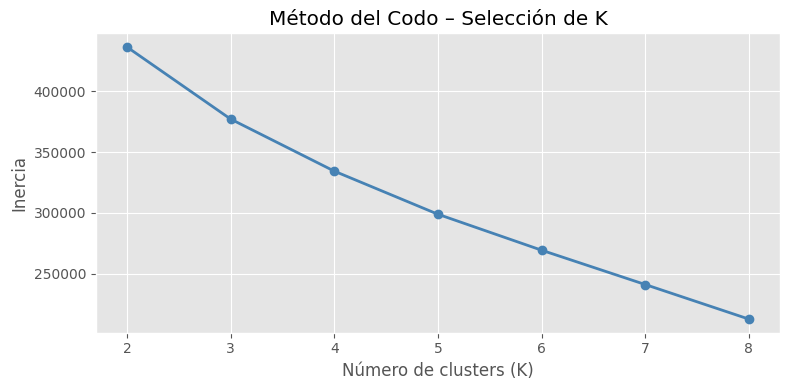

K=2: inercia=436517
K=3: inercia=377185
K=4: inercia=334310
K=5: inercia=298815
K=6: inercia=269211
K=7: inercia=240952
K=8: inercia=212481


In [57]:
# Método del codo
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.title('Método del Codo – Selección de K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f'K={k}: inercia={inertia:.0f}')

La reducción de inercia se aplana notoriamente a partir de **K=3**, donde la ganancia marginal al agregar más clusters disminuye. Se selecciona **K=3** como valor óptimo, que además coincide con la categorización natural del negocio: propiedades económicas, intermedias y premium.

In [58]:
K_OPTIMO = 3
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_clust['cluster'] = km_final.fit_predict(X_scaled)

print('Media por cluster:')
print(df_clust.groupby('cluster')[cluster_features].mean().round(2).to_string())
print('\nMediana de price por cluster:')
print(df_clust.groupby('cluster')['price'].agg(['median','mean','count']))

Media por cluster:
            price  accommodates  bedrooms  beds  bathrooms  minimum_nights  availability_365  number_of_reviews  review_scores_rating
cluster                                                                                                                              
0          203.29          3.56      1.24  1.87       1.24            8.12            227.29              72.78                  4.79
1          552.98          8.64      3.46  5.06       2.66            5.40            235.75              46.82                  4.85
2        47681.39          5.83      1.74  1.05       1.64            1.01            208.34               5.55                  4.63

Mediana de price por cluster:
          median          mean  count
cluster                              
0          153.0    203.289874  46910
1          359.0    552.976668  15644
2        50000.0  47681.386905    168


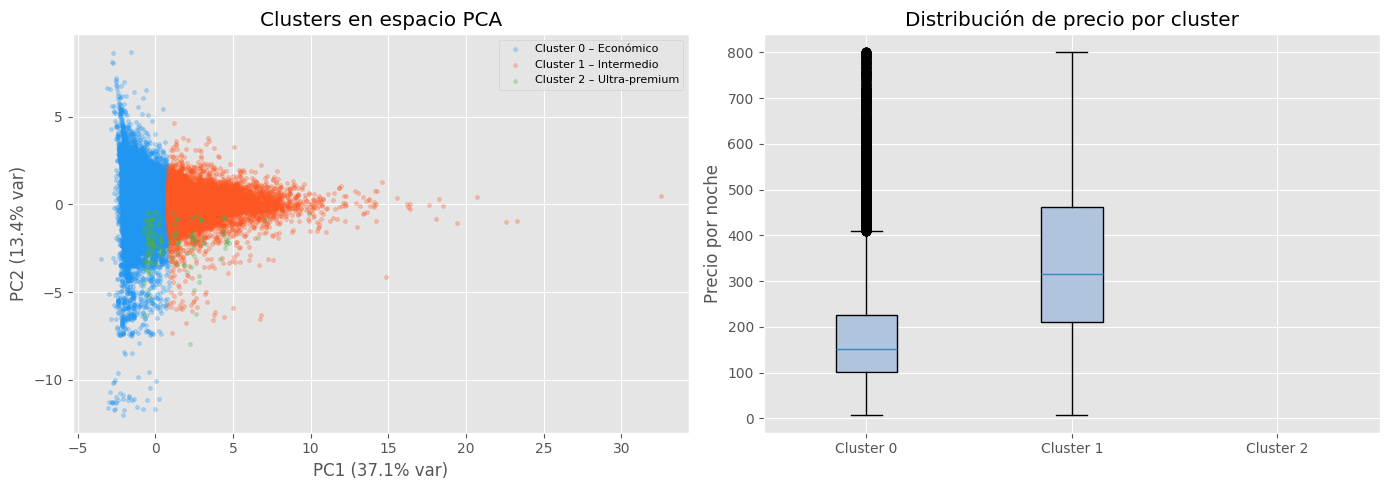

Varianza explicada PC1+PC2: 50.4%


In [59]:
# Visualización PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#FF5722', '#4CAF50']
labels = ['Cluster 0 – Económico', 'Cluster 1 – Intermedio', 'Cluster 2 – Ultra-premium']
for i in range(K_OPTIMO):
    mask = df_clust['cluster'].values == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=labels[i], alpha=0.3, s=8)
axes[0].set_title('Clusters en espacio PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(fontsize=8)

p95 = df_clust['price'].quantile(0.95)
df_viz = df_clust[df_clust['price'] <= p95]
axes[1].boxplot(
    [df_viz[df_viz['cluster'] == i]['price'].values for i in range(K_OPTIMO)],
    labels=[f'Cluster {i}' for i in range(K_OPTIMO)],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue')
)
axes[1].set_title('Distribución de precio por cluster')
axes[1].set_ylabel('Precio por noche')

plt.tight_layout()
plt.show()
print(f'Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}')

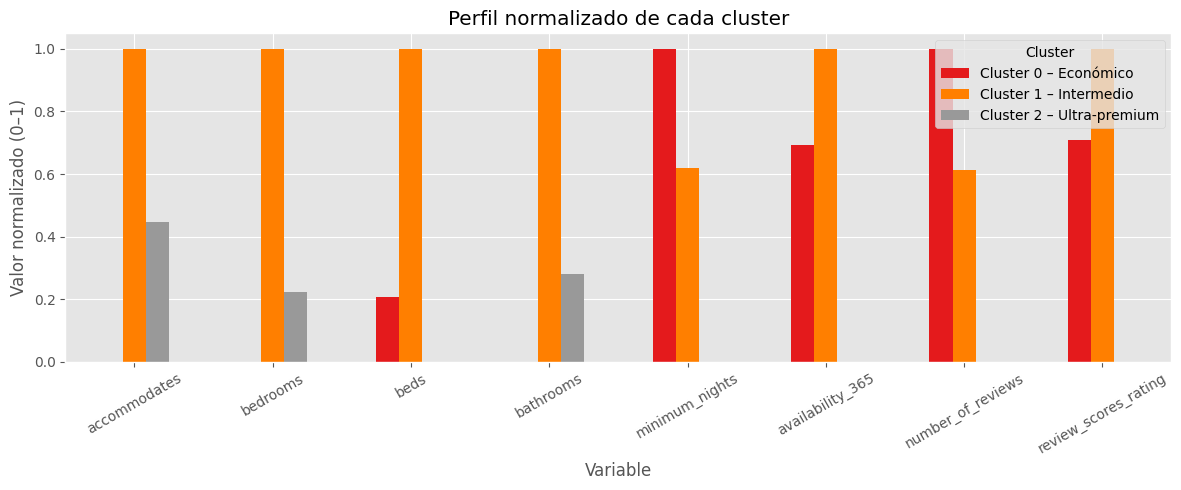

In [60]:
# Perfil normalizado por cluster
profile_vars = [c for c in cluster_features if c != 'price']
cluster_profile = df_clust.groupby('cluster')[profile_vars].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / \
                       (cluster_profile.max() - cluster_profile.min())

cluster_profile_norm.T.plot(kind='bar', figsize=(12, 5), colormap='Set1')
plt.title('Perfil normalizado de cada cluster')
plt.xlabel('Variable')
plt.ylabel('Valor normalizado (0–1)')
plt.legend(title='Cluster', labels=labels)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretación de los clusters:**

| Cluster | Descripción | Precio mediano | Capacidad media | Tamaño |
|---|---|---|---|---|
| **0 – Económico** | Propiedades pequeñas, mayor número de reseñas, alta rotación | $153 | 3.6 huéspedes | 46,910 (75%) |
| **1 – Intermedio/Premium** | Alojamientos más grandes, familias, mayor precio | $359 | 8.6 huéspedes | 15,644 (25%) |
| **2 – Ultra-premium/Outliers** | Solo 168 propiedades con precios extremos (~$50,000). Probablemente hoteles de lujo o errores de datos. | $50,000 | 5.8 huéspedes | 168 (<1%) |

**Conclusión:** El cluster 2 es claramente anómalo — propiedades con precios de $50,000/noche no corresponden al perfil típico de Airbnb y pueden distorsionar los modelos. Para las actividades de modelado se considerará si conviene filtrarlos.

---
## Actividad 4 – División Train / Test

In [61]:
y = df_model['price']
X = df_model.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, train_size=0.70, random_state=42
)

# Identificar columnas numéricas y categóricas para el Pipeline
numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print('=== Criterio de division ===')
print(f'  Proporcion:    70% entrenamiento / 30% prueba')
print(f'  Filas totales: {len(df_model):,}')
print(f'  Train:         {len(X_train):,} filas')
print(f'  Test:          {len(X_test):,} filas')
print(f'  Semilla:       42 (reproducibilidad)')
print(f'\n  Cols numericas:   {len(numerical_columns)}')
print(f'  Cols categoricas: {len(categorical_columns)} -> {categorical_columns}')
print()
print(pd.DataFrame({'Train': y_train.describe(), 'Test': y_test.describe()}).round(2))

=== Criterio de division ===
  Proporcion:    70% entrenamiento / 30% prueba
  Filas totales: 76,246
  Train:         53,372 filas
  Test:          22,874 filas
  Semilla:       42 (reproducibilidad)

  Cols numericas:   46
  Cols categoricas: 8 -> ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'estimated_revenue_l365d', 'city']

          Train      Test
count  53372.00  22874.00
mean     747.00    758.69
std     4245.56   4262.44
min        8.00      9.00
25%      120.00    121.00
50%      192.00    194.00
75%      325.00    330.00
max    50123.00  50020.00


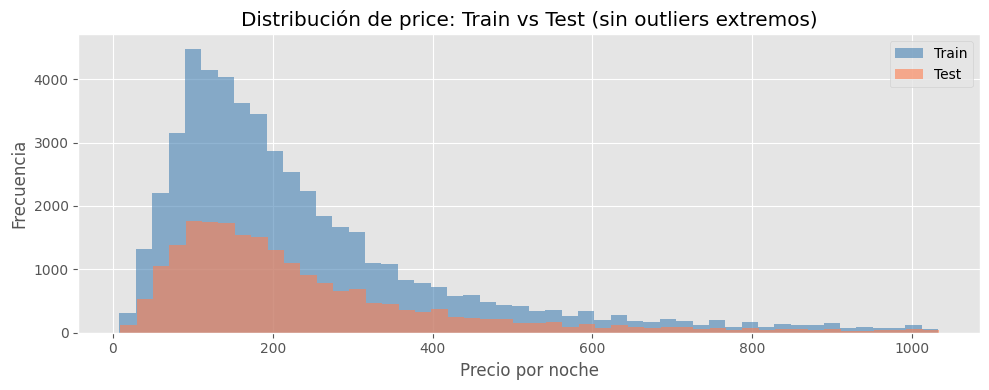

In [62]:
p95 = y.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train[y_train <= p95], bins=50, alpha=0.6, label='Train', color='steelblue')
ax.hist(y_test[y_test <= p95], bins=50, alpha=0.6, label='Test', color='coral')
ax.set_title('Distribución de price: Train vs Test (sin outliers extremos)')
ax.set_xlabel('Precio por noche')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Criterio de división:**
- Se utilizó una proporción **70/30** (53,372 train / 22,874 test), consistente con el estándar del curso.
- La división **no se estratificó** ya que `price` es variable continua.
- Se fijó `random_state=42` para garantizar reproducibilidad.
- Las distribuciones de `price` en train y test son prácticamente idénticas (mediana $192 train / $194 test), confirmando que la partición es representativa.

---
## Actividad 5 – Árbol de Regresión (todas las variables)

In [63]:
# Preprocesador: OneHotEncoder para categóricas, passthrough para numéricas
categorical_preprocessor = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns)
], remainder='passthrough')

# Pipeline: preprocesamiento + árbol de regresión sin restricciones
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

pipeline_tree.fit(X_train, y_train)

yp_train = pipeline_tree.predict(X_train)
yp_test  = pipeline_tree.predict(X_test)

mae_tr  = mean_absolute_error(y_train, yp_train)
mae_te  = mean_absolute_error(y_test,  yp_test)
mse_tr  = mean_squared_error(y_train,  yp_train)
mse_te  = mean_squared_error(y_test,   yp_test)
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)

print(f'{"Metrica":<10} {"Train":>12} {"Test":>12}')
print('-' * 36)
print(f'{"MAE":<10} {mae_tr:>12.2f} {mae_te:>12.2f}')
print(f'{"MSE":<10} {mse_tr:>12.2f} {mse_te:>12.2f}')
print(f'{"RMSE":<10} {rmse_tr:>12.2f} {rmse_te:>12.2f}')

tree_model = pipeline_tree.named_steps['regressor']
print(f'\nProfundidad del arbol: {tree_model.get_depth()}')
print(f'Numero de hojas:       {tree_model.get_n_leaves():,}')

Metrica           Train         Test
------------------------------------
MAE                1.53       204.02
MSE             7344.52   2741910.12
RMSE              85.70      1655.87

Profundidad del arbol: 89
Numero de hojas:       47,808


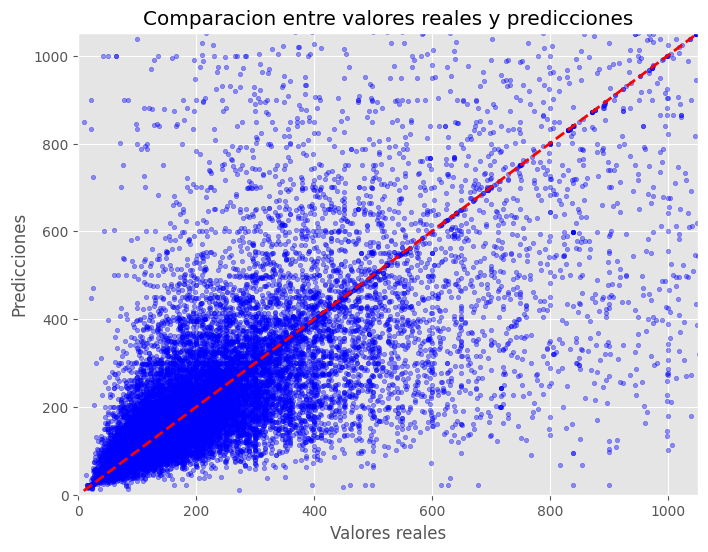

In [64]:
# Gráfica 1: Real vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, yp_test, color='blue', alpha=0.4, s=10)
lim = y_test.quantile(0.95)
plt.plot([y_test.min(), lim], [y_test.min(), lim], 'r--', lw=2)
plt.title('Comparacion entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.show()

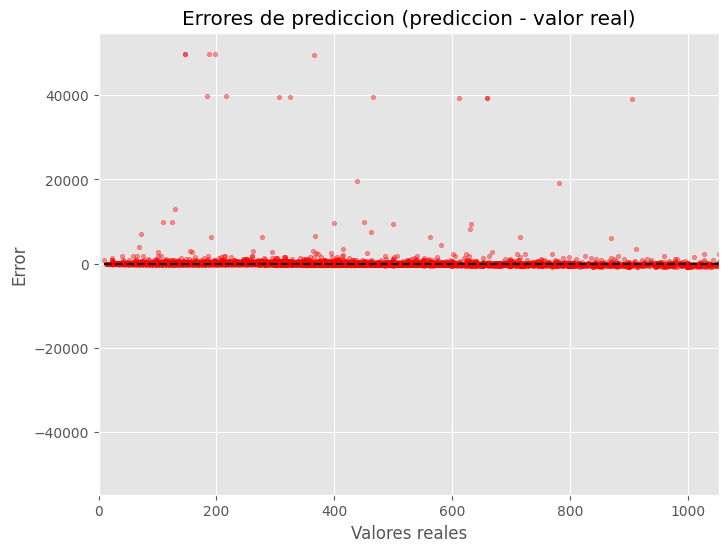

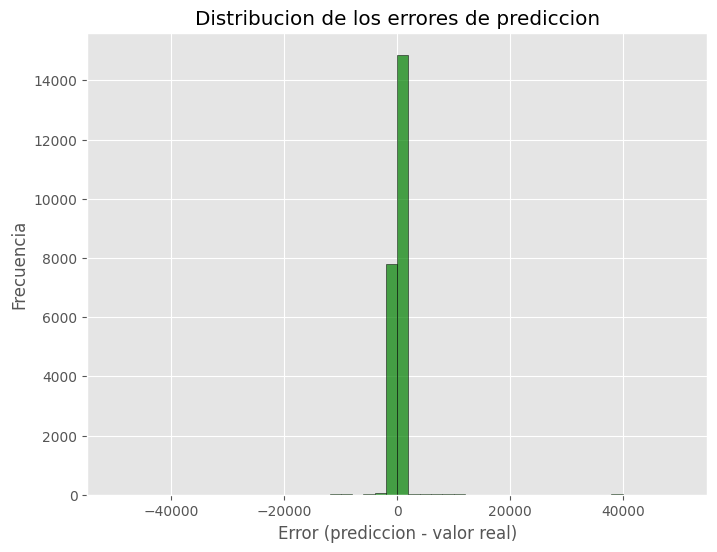

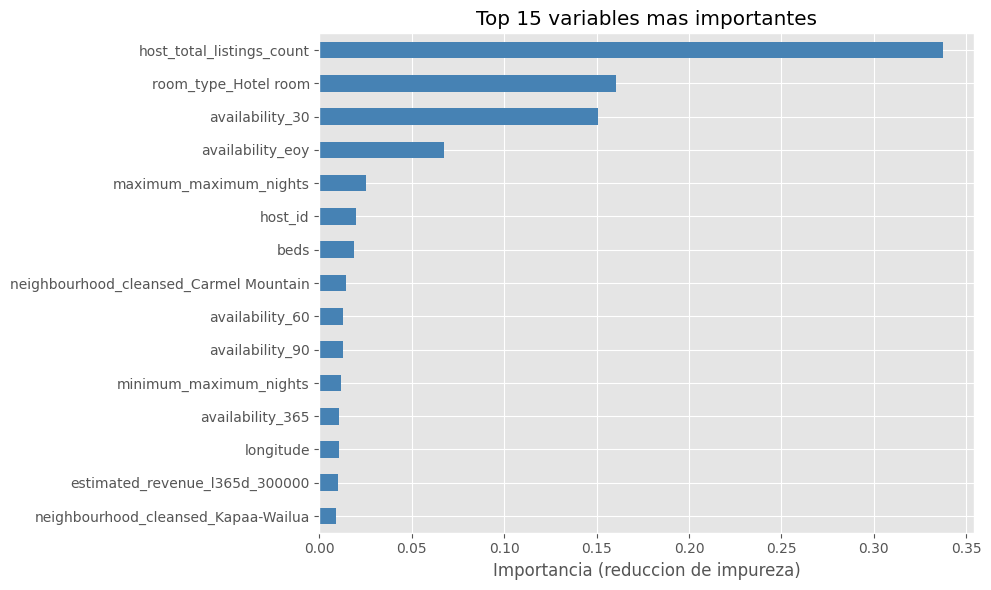

Top 15 variables:
neighbourhood_cleansed_Kapaa-Wailua       0.0090
estimated_revenue_l365d_300000            0.0102
longitude                                 0.0104
availability_365                          0.0106
minimum_maximum_nights                    0.0115
availability_90                           0.0125
availability_60                           0.0126
neighbourhood_cleansed_Carmel Mountain    0.0143
beds                                      0.0188
host_id                                   0.0196
maximum_maximum_nights                    0.0251
availability_eoy                          0.0675
availability_30                           0.1507
room_type_Hotel room                      0.1607
host_total_listings_count                 0.3373


In [65]:
# Gráfica 2: Errores vs valores reales
errores = yp_test - y_test
plt.figure(figsize=(8, 6))
plt.scatter(y_test, errores, color='red', alpha=0.4, s=10)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.quantile(0.95),
           colors='black', linestyles='dashed')
plt.title('Errores de prediccion (prediccion - valor real)')
plt.xlabel('Valores reales')
plt.ylabel('Error')
plt.xlim(0, y_test.quantile(0.95))
plt.show()

# Gráfica 3: Distribución de errores
plt.figure(figsize=(8, 6))
plt.hist(errores, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribucion de los errores de prediccion')
plt.xlabel('Error (prediccion - valor real)')
plt.ylabel('Frecuencia')
plt.show()

# Importancia de variables (top 15)
ohe_features = pipeline_tree.named_steps['preprocessor']\
    .named_transformers_['one-hot-encoder']\
    .get_feature_names_out(categorical_columns).tolist()
all_features = ohe_features + numerical_columns

importances = pd.Series(tree_model.feature_importances_, index=all_features)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 variables mas importantes')
plt.xlabel('Importancia (reduccion de impureza)')
plt.tight_layout()
plt.show()

print('Top 15 variables:')
print(top15.round(4).to_string())

**Análisis del árbol de regresión sin restricciones:**

| Métrica | Train | Test |
|---|---|---|
| MAE | 1.53 | 204.02 |
| MSE | 7,344.52 | 2,741,910.12 |
| RMSE | 85.70 | 1,655.87 |

- **Overfitting severo:** El árbol creció hasta **89 niveles** con **47,808 hojas**, memorizando el conjunto de entrenamiento. El MAE en train es $1.53 pero en test sube a $204, evidencia clara de que el modelo no generaliza.
- **Variables más importantes:** `host_total_listings_count` (33.7%) domina, seguido de `room_type_Hotel room` (16.1%) y `availability_30` (15.1%). La alta importancia de `host_total_listings_count` indica que el árbol está aprendiendo patrones muy específicos de anfitriones individuales en lugar de características generalizables de las propiedades.
- **Real vs Predicho:** El modelo predice aceptablemente en rangos de precio bajos pero falla en propiedades de precio alto, produciendo predicciones fuera de rango.
- **Distribución de errores:** Centrada cerca de 0 pero con cola derecha pronunciada, evidenciando subestimación sistemática en propiedades caras.

**Conclusión:** Es necesario regularizar el árbol restringiendo la profundidad máxima (`max_depth`). Esto se abordará en la Actividad 7.